# **Camada Recorrente**

#**Célula Recorrente Básica**

##Dados de entrada

In [ ]:
import os
import numpy as np
import unicodedata

def le_arquivo(path):
  nomes = open(path).read().split('\n')
  nomes = [unicodedata.normalize('NFKD', nome).encode('ascii', 'ignore') for nome in nomes ]
  categoria = path.split('/')[-1].split('.')[0]
  categorias = np.repeat(categoria, len(nomes))

  return nomes, categorias

root = './data/names/'
arquivos = sorted(os.listdir(root))

dados, rotulos = [], []
for arquivo in arquivos:
  nomes, nacionalidades = le_arquivo(os.path.join(root, arquivo))

  dados.append(nomes)
  rotulos.append(nacionalidades)

dados[0][0:10], rotulos[0][0:10]


([b'Khoury',
  b'Nahas',
  b'Daher',
  b'Gerges',
  b'Nazari',
  b'Maalouf',
  b'Gerges',
  b'Naifeh',
  b'Guirguis',
  b'Baba'],
 array(['Arabic', 'Arabic', 'Arabic', 'Arabic', 'Arabic', 'Arabic',
        'Arabic', 'Arabic', 'Arabic', 'Arabic'], dtype='<U6'))

##Covertendo os dados para tensor

In [ ]:
# Convertendo os rótulos para tensor
import torch

categorias = [arquivo.split('.')[0] for arquivo in arquivos]

def label2tensor(str):
  posicao = categorias.index(str)
  return torch.LongTensor([posicao])

rotulos[8][10], label2tensor(rotulos[8][10])


(np.str_('Irish'), tensor([8]))

In [ ]:
# Convertendo os nomes para tensor
import string
import torch

dicionario = string.ascii_letters  + "  '-"

def name2tensor(name):
  name_decoded = name.decode('utf-8')
  # Filter characters to ensure they are in the dictionary
  filtered_name = ''.join([letra for letra in name_decoded if letra in dicionario])

  name_tns = torch.zeros(len(filtered_name), len(dicionario))
  for k, letra in enumerate(filtered_name):
    name_tns[k][dicionario.index(letra)] = 1

  return name_tns

print(dicionario)
dados[0][10].decode('utf-8')[0], name2tensor(dados[0][10])[0]

abcdefghijklmnopqrstuvwxyzABCDEFGHIJKLMNOPQRSTUVWXYZ  '-


('S',
 tensor([0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.]))

In [ ]:
#Amostrando conjunto balanceado

def amostrar(num_amostras):
  dados_amostra, rotulos_amostra = [], []

  for cat in categorias:
    num_nomes = len(dados[categorias.index(cat)])

    indices = np.random.choice(range(num_nomes), size=num_amostras)
    dados_amostra.extend( [dado for idx, dado in enumerate(dados[categorias.index(cat)]) if idx in indices ] )
    rotulos_amostra.extend( [rotulo for idx, rotulo in enumerate(rotulos[categorias.index(cat)]) if idx in indices ] )

  dados_amostra = [name2tensor(nome) for nome in dados_amostra]
  rotulos_amostra = [label2tensor(rotulo) for rotulo in rotulos_amostra]

  return dados_amostra, rotulos_amostra

num_amostras = 50
dados_tns, rotulos_tns = amostrar(num_amostras)

print(len(dados_tns), len(rotulos_tns))
print(dados_tns[10], rotulos_tns[10])

826 826
tensor([[0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0.],
        [0., 0., 0., 0., 1., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0., 0.,
         0., 0., 0., 0., 0., 0., 0., 0., 0., 0.

## Modelo Recorrente

In [ ]:
import torch
from torch import nn

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')

device

device(type='cuda')

In [ ]:
class RNN(nn.Module):
  def __init__(self, tam_entrada, tam_hidden, tam_saida):
    super().__init__() # Call the parent class's constructor

    self.tam_hidden = tam_hidden
    self.recurrent = nn.RNNCell( tam_entrada, tam_hidden )
    self.saida = nn.Linear(tam_hidden, tam_saida)
    self.ativacao = nn.LogSoftmax(dim=1)

  def forward(self, nome):
    #inicializar a memoria interna / feature / hidden state
    h = torch.zeros(1, self.tam_hidden).to(device)


    # num_letras x 55 - 55
    for letra in nome:
      h = self.recurrent(letra.unsqueeze(0), h) # 1 x 55 -> B x N

    saida = self.ativacao(self.saida(h))
    return saida

modelo = RNN(len(dicionario), 256, len(categorias)).to(device)
print(modelo)

RNN(
  (recurrent): RNNCell(56, 256)
  (saida): Linear(in_features=256, out_features=18, bias=True)
  (ativacao): LogSoftmax(dim=1)
)


## Loss e Otimizador

In [ ]:
args = {'lr': 5e-5, 'weight_decay': 1e-7}
criterio = nn.NLLLoss().to(device)
optimizer = torch.optim.Adam(modelo.parameters(), lr=args['lr'], weight_decay=args['weight_decay'])


## Treinamento

In [ ]:
def forward(X, Y, etapa, epoca):

  acuracia = 0.
  loss_epoca = []
  for dado, rotulo in zip(X, Y):
    dado = dado.to(device)
    rotulo = rotulo.to(device)

    saida = modelo(dado) # B x C = 1 x 18
    loss = criterio(saida, rotulo)
    loss_epoca.append(loss)

    _, pred = torch.max(saida, axis=-1)
    acuracia += 1 if pred[0].item() == rotulo[0].item() else 0

    if etapa == 'treino':
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

  # Move tensors to CPU before converting to numpy
  loss_epoca = np.array([l.cpu().detach().numpy() for l in loss_epoca])
  acuracia = acuracia/float(len(X))

  print('\n', '*'*15 + etapa + '*'*15)
  print('Epoca: {:}, Loss: {:.2f} +/- {:.2f}, Acc: {:.2f}'.format(epoca, loss_epoca.mean(), loss_epoca.std(), acuracia*100))

  return loss_epoca.mean(), acuracia

In [ ]:
loss_treino, loss_teste = [], []
acc_treino, acc_teste = [], [] # Corrected: initialize acc_teste here

dados_teste, rotulos_teste = amostrar(50)

for epoca in range(100):

  dados_tns, rotulos_tns = amostrar(50)
  loss, acc = forward(dados_tns, rotulos_tns, 'treino', epoca)
  loss_treino.append(loss)
  acc_treino.append(acc)

  loss, acc = forward(dados_teste, rotulos_teste, 'teste', epoca)
  loss_teste.append(loss)
  acc_teste.append(acc)


 ***************treino***************
Epoca: 0, Loss: 2.81 +/- 0.42, Acc: 6.51

 ***************teste***************
Epoca: 0, Loss: 3.01 +/- 0.53, Acc: 4.95

 ***************treino***************
Epoca: 1, Loss: 2.74 +/- 0.54, Acc: 7.92

 ***************teste***************
Epoca: 1, Loss: 3.15 +/- 0.82, Acc: 5.45

 ***************treino***************
Epoca: 2, Loss: 2.79 +/- 0.58, Acc: 6.83

 ***************teste***************
Epoca: 2, Loss: 3.07 +/- 0.76, Acc: 5.82

 ***************treino***************
Epoca: 3, Loss: 2.79 +/- 0.52, Acc: 6.36

 ***************teste***************
Epoca: 3, Loss: 3.05 +/- 0.73, Acc: 6.56

 ***************treino***************
Epoca: 4, Loss: 2.79 +/- 0.48, Acc: 7.21

 ***************teste***************
Epoca: 4, Loss: 2.94 +/- 0.50, Acc: 9.16

 ***************treino***************
Epoca: 5, Loss: 2.78 +/- 0.43, Acc: 9.93

 ***************teste***************
Epoca: 5, Loss: 2.92 +/- 0.46, Acc: 12.13

 ***************treino***************
Epoca:

KeyboardInterrupt: 

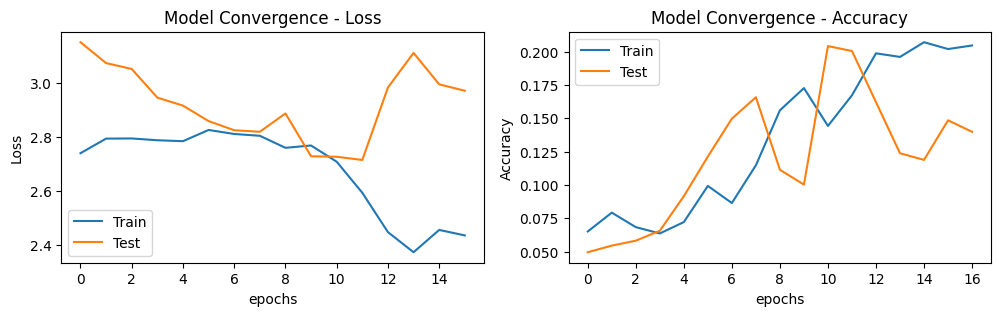

In [ ]:
import matplotlib.pyplot as plt
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12,3))

ax1.plot(loss_treino[1:], label='Train')
ax1.plot(loss_teste[1:], label='Test')
ax1.set_title('Model Convergence - Loss')
ax1.set_xlabel('epochs')
ax1.set_ylabel('Loss')
ax1.legend()

ax2.plot(acc_treino, label='Train')
ax2.plot(acc_teste, label='Test')
ax2.set_title('Model Convergence - Accuracy')
ax2.set_xlabel('epochs')
ax2.set_ylabel('Accuracy')
ax2.legend()

In [ ]:
class RNN(nn.Module):
  def __init__(self, tam_entrada, tam_hidden, tam_saida):
    super().__init__() # Call the parent class's constructor

    self.tam_hidden = tam_hidden
    self.recurrent = nn.GRU( tam_entrada, tam_hidden, batch_first=False )
    self.saida = nn.Linear(tam_hidden, tam_saida)
    self.ativacao = nn.LogSoftmax(dim=1)

  def forward(self, nome):

    print('Nome inicial', nome.size())
    #inicializar a memoria interna / feature / hidden state
    # B x F -> L x B x F
    h = torch.zeros(1, 1, self.tam_hidden).to(device)
    print('H inicial', h.size())

    # S x B x N -> B x S x N
    nome = nome.unsqueeze(1) # S x N -> S x 1 x N
    print('Nome atualizado', nome.size())
    saida, h = self.recurrent(nome)
    # S x B x F -> L x B x F
    saida = self.ativacao(self.saida(saida[-1]))
    print('Saida classificação', saida.size())
    return saida

modelo = RNN(len(dicionario), 256, len(categorias)).to(device)
print(modelo)

RNN(
  (recurrent): GRU(56, 256)
  (saida): Linear(in_features=256, out_features=18, bias=True)
  (ativacao): LogSoftmax(dim=1)
)


In [ ]:
saida = modelo(dados_tns[0].to(device))

Nome inicial torch.Size([5, 56])
H inicial torch.Size([1, 1, 256])
Nome atualizado torch.Size([5, 1, 56])
Saida classificação torch.Size([1, 18])


#**Sequências de Tamanho Variável**

##Torchtext

In [ ]:
import os, random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('darkgrid')

import torch
from torch import nn, optim
from torchtext import data
from torchtext import datasets
import torch.nn.functional as F

SEED = 1234
torch.manual_seed(SEED)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

In [ ]:
TEXT = data.Field(tokenize = 'spacy', include_lenghts = True)
LABEL = data.LabelField(dtype = torch.long)

train, test = datasets.IMDB.splits(TEXT, LABEL)

In [ ]:
for amostra in test:
  print(vars(amostra))
  break

## Representação de dados

In [ ]:
TEXT.build_vocab(train_data,
                 max_size = MAX_VOCAB_SIZE,
                 vectors = "glove.6B.100d",
                 unk_init = torch.Tensor.normal_)

LABEL.build_vocab(train_data)

In [ ]:
print('Tamanho do vocabulario', len(TEXT.vocab),'\n')
print(TEXT.vocab.itos[:10],'\n', LABEL.vocab.stoi, '\n')
TEXT.vocab.freqs.most_common(20)

##Embedding Layer

In [ ]:
class RNN(nn.Module):

  def __init__(self, tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad):
    super(RNN, self).__init__()

    # Inicializaremos a camada de embedding
    self.embedding = nn.Embedding(tam_vocab, tam_embedding)
    self.embedding.weight.data.copy_(embed_vectors)
    self.embedding.weight.data[ind_unk] = torch.zeros(tam_embedding)
    self.embedding.weight.data[ind_pad] = torch.zeros(tam_embedding)
    #######################################


  def forward(self, X):
    vectors = self.embedding(X)


tam_vocab = len(TEXT.vocab)
tam_embedding = 100 # glove 100d
embed_vectors = TEXT.vocab.vectors
ind_pad = TEXT.vocab.stoi[TEXT.pad_token]
ind_unk = TEXT.vocab.stoi[TEXT.unk_token]

model = RNN(tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad)

print(model)

##BucketIterator

In [ ]:
BATCH_SIZE = 64

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

train_iterator, valid_iterator, test_iterator = data.BucketIterator.splits(
    (train_data, valid_data, test_data),
    batch_size = BATCH_SIZE,
    sort_within_batch = True,
    device = device)

In [ ]:
for sample in valid_iterator:

  texto, tamanho = sample.text
  label = sample.label

  print(f'Texto: {texto.shape}, Tamanho: {tamanho.shape}, Label: {label.shape} \n', )

  print(tamanho)

  break

## Padding and Packing

In [ ]:
class RNN(nn.Module):

  def __init__(self, tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size):
    super(RNN, self).__init__()

    # Inicializaremos a camada de embedding
    self.embedding = nn.Embedding(tam_vocab, tam_embedding)
    self.embedding.weight.data.copy_(embed_vectors)
    self.embedding.weight.data[ind_unk] = torch.zeros(tam_embedding)
    self.embedding.weight.data[ind_pad] = torch.zeros(tam_embedding)
    #######################################

    # Camada recorrente
    self.hidden_size = hidden_size
    self.rnn = nn.GRU(tam_embedding, hidden_size)


  def forward(self, X, tamanhos):
    print('X:', X.size(), '\n')
    print('tamanhos', tamanhos, '\n')
    vectors = self.embedding(X)
    print('Vectors:', vectors.size(), '\n')

    hidden = torch.randn(1, X.size(1), self.hidden_size)

    ## Empacote a sequência antes de alimentar a unidade recorrente
    packed_input = nn.utils.rnn.pack_padded_sequence(vectors, tamanhos)
    print('Packed input:', packed_input.batch_sizes, '\n')

    ## Forward recorrente
    packed_output, hidden = self.rnn(packed_input, hidden )
    print('Packed output:', packed_output.batch_sizes, '\n')

    ## Desempacote a sequência para continuar o fluxo na rede.
    output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output)
    print('output:', output.size(), '\n')

    return output


tam_vocab = len(TEXT.vocab)
tam_embedding = 100 # glove 100d
embed_vectors = TEXT.vocab.vectors
ind_pad = TEXT.vocab.stoi[TEXT.pad_token]
ind_unk = TEXT.vocab.stoi[TEXT.unk_token]

hidden_size = 256

model = RNN(tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size)

print(model)

In [ ]:
for sample in valid_iterator:
  texto, tamanhos = sample.text
  label = sample.label

  saida = model(texto, tamanhos)
  break

## Classificando Sequências

In [ ]:
class RNN(nn.Module):

  def __init__(self, tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size, output_size):
    super(RNN, self).__init__()

    # Inicializaremos a camada de embedding
    self.embedding = nn.Embedding(tam_vocab, tam_embedding)
    self.embedding.weight.data.copy_(embed_vectors)
    self.embedding.weight.data[ind_unk] = torch.zeros(tam_embedding)
    self.embedding.weight.data[ind_pad] = torch.zeros(tam_embedding)
    #######################################

    self.hidden_size = hidden_size
    self.rnn = nn.GRU(tam_embedding, hidden_size)
    self.linear = nn.Linear(hidden_size, output_size)


  def forward(self, X, tamanhos):
    vectors = self.embedding(X)

    hidden = torch.zeros(1, X.size(1), self.hidden_size).to(device)

    packed_input = nn.utils.rnn.pack_padded_sequence(vectors, tamanhos)
    packed_output, hidden = self.rnn(packed_input, hidden )
    output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output)

    # print('output:', output.size())
    output = F.adaptive_max_pool1d(output.permute(1,2,0), 1)
    # print('output pool:', output.size())
    output = self.linear(output.squeeze())
    # print('output linear:', output.size())

    return output


tam_vocab = len(TEXT.vocab)
tam_embedding = 100 # glove 100d
embed_vectors = TEXT.vocab.vectors
ind_pad = TEXT.vocab.stoi[TEXT.pad_token]
ind_unk = TEXT.vocab.stoi[TEXT.unk_token]

hidden_size = 256
output_size = 2

model = RNN(tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size, output_size)

model = model.to(device)

print(model)

In [ ]:
for sample in valid_iterator:
  texto, tamanhos = sample.text
  label = sample.label

  saida = model(texto, tamanhos.cpu())
  break

### Loss e Otimizador

In [ ]:
criterio = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-5)

def forward(iterator, num_samples, etapa):
  if etapa == 'Treino': model.train()
  else: model.eval()

  acuracia = 0.
  loss_epoca = []
  for k, sample in enumerate(iterator):

    texto, tamanhos = sample.text
    rotulo = sample.label

    saida = model(texto, tamanhos.cpu())

    loss = criterio(saida, rotulo)
    loss_epoca.append(loss.detach().cpu().numpy())

    _, pred = torch.max(saida, axis=-1)
    acuracia += (pred.cpu().data == rotulo.cpu().data).sum()

    if etapa == 'Treino':
      # Otimização
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

  loss_epoca = np.asarray(loss_epoca).ravel()
  acuracia   = acuracia/float(num_samples)
  print('\n','*'*15 + etapa + '*'*15 )
  print('Epoca: {:}, Loss: {:.4f} +/- {:.4f}, Acurácia: {:.4f}'.format(epoca, loss_epoca.mean(),
                                                                        loss_epoca.std(),
                                                                        acuracia
                                                                       ))
  return loss_epoca.mean(), acuracia

In [11]:
loss_treino, loss_test = [], []
acc_treino, acc_test = [], []

for epoca in range(25):
  loss, acuracia = forward(train_iterator, len(train_data), 'Treino')
  loss_treino.append(loss)
  acc_treino.append(acuracia)

  loss, acuracia = forward(valid_iterator, len(valid_data), 'Teste')
  loss_test.append(loss)
  acc_test.append(acuracia)


In [ ]:
import spacy
nlp = spacy.load('en')

def predict_sentiment(sentence):
    model.eval()
    tokenized = [str(tok) for tok in nlp.tokenizer(sentence)]
    print(tokenized)

    indexed = [TEXT.vocab.stoi[t] for t in tokenized]
    length = [len(indexed)]
    print(indexed)

    tensor = torch.LongTensor(indexed).to(device)
    tensor = tensor.unsqueeze(1)
    length_tensor = torch.LongTensor(length)

    prediction = model(tensor, length_tensor)

    return F.softmax(prediction, dim=-1).cpu().data

In [ ]:
np.random.seed(42)
for i in range(5):
  idx = np.random.choice(len(test_data))
  text = test_data[idx].text
  pred = predict_sentiment(' '.join(text) )

  plt.bar(0, pred[0], color='darkred', label='Negativo', width=0.5)
  plt.bar(1, pred[1], color='dodgerblue', label='Positivo', width=0.5)
  plt.title(str(test_data[idx].label))
  plt.legend()
  plt.show()